In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

In [18]:
import seaborn as sns

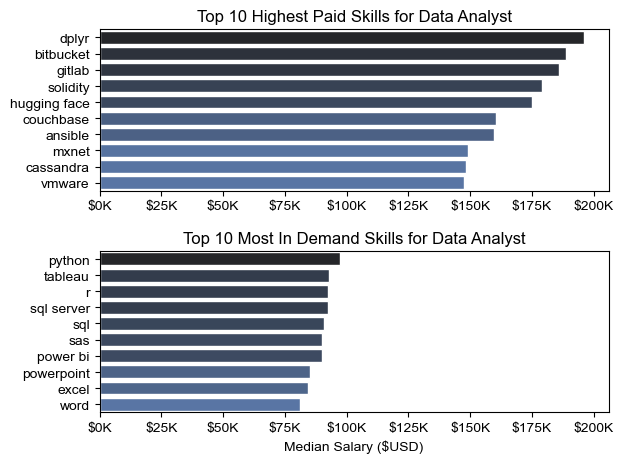

In [29]:
fig, ax = plt.subplots(2, 1)
axes = plt.gca()
sns.set_theme(style="ticks")

df_da_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_da_us = df_da_us.dropna(subset='salary_year_avg')
df_da_us_explode = df_da_us.explode('job_skills')
df_da_us_group = df_da_us_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_da_us_high_pay = df_da_us_group.sort_values(by='median', ascending=False).head(10)
df_da_us_skills = df_da_us_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

sns.barplot(data=df_da_us_high_pay, x='median', y=df_da_us_high_pay.index, ax=ax[0], hue='median', palette='dark:b_r')
ax[0].legend().remove()
# df_da_us_high_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analyst')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].axes.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

sns.barplot(data=df_da_us_skills, x='median', y=df_da_us_skills.index, ax=ax[1], hue='median', palette='dark:b_r')
ax[1].legend().remove()
# df_da_us_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In Demand Skills for Data Analyst')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].axes.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

fig.tight_layout()

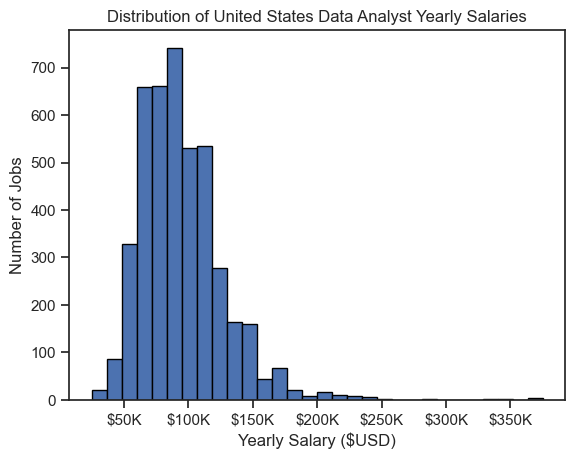

In [34]:
df_da_us['salary_year_avg'].plot(kind='hist', bins=30, edgecolor='black')

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.show()

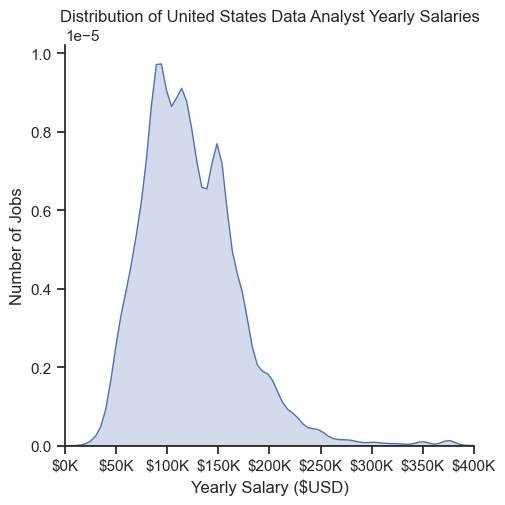

In [39]:
sns.displot(df['salary_year_avg'], kind='kde', fill=True)

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('Number of Jobs')
plt.xlim(0, 400000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.show()

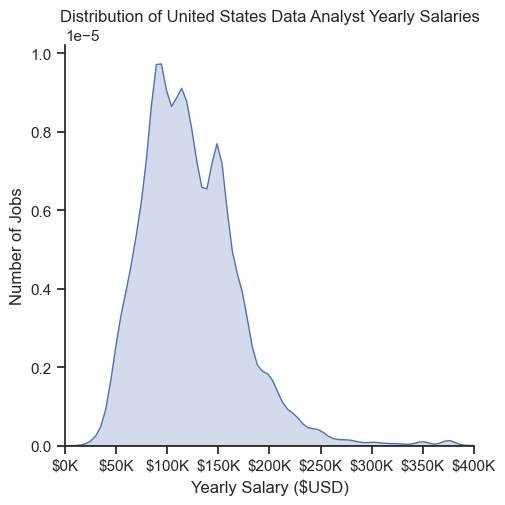

In [40]:
sns.set_theme(style="ticks")
sns.displot(df['salary_year_avg'], kind='kde', fill=True)

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('Number of Jobs')
plt.xlim(0, 400000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.show()

C:\Users\SHARATSAI\AppData\Local\Temp\ipykernel_34920\1779338009.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  job_list = [df_us[df['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]
C:\Users\SHARATSAI\AppData\Local\Temp\ipykernel_34920\1779338009.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  job_list = [df_us[df['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]
C:\Users\SHARATSAI\AppData\Local\Temp\ipykernel_34920\1779338009.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  job_list = [df_us[df['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]
C:\Users\SHARATSAI\AppData\Local\Temp\ipykernel_34920\1779338009.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.b

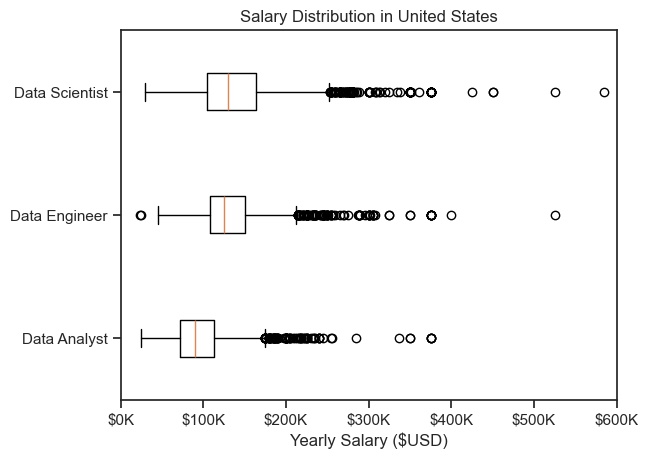

In [42]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_us = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])

job_list = [df_us[df['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution in United States')
plt.xlabel('Yearly Salary ($USD)')
plt.xlim(0, 600000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${(int(x/1000))}K'))
plt.show()

C:\Users\SHARATSAI\AppData\Local\Temp\ipykernel_34920\1767735668.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  job_list = [df_us[df['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]
C:\Users\SHARATSAI\AppData\Local\Temp\ipykernel_34920\1767735668.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  job_list = [df_us[df['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]
C:\Users\SHARATSAI\AppData\Local\Temp\ipykernel_34920\1767735668.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  job_list = [df_us[df['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]


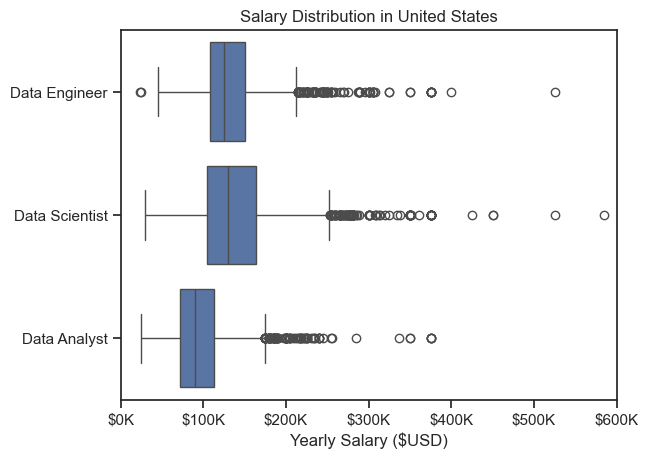

In [45]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_us = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])

job_list = [df_us[df['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

sns.boxplot(data=df_us, x='salary_year_avg', y='job_title_short')

plt.title('Salary Distribution in United States')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
plt.xlim(0, 600000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${(int(x/1000))}K'))
plt.show()